# _tobac_ example: deep convective clouds tracking using eroded-contiguity

In this example, we will introduc eroded-contiguity tracking of deep convective clouds in km-scale ICON simulations. This example will consist of the following sections:

  1. Accessing model data and conversion of healpix grid data to a regular lat/lon grid for tracking
  2. Feature detection, segmentation and _tobac_ centroid-tracking of (i) updrafts and (ii) ice clouds in 3D
  3. Extra tracking of (i) and (ii) using eroded-contiguity
  4. Combining the results of each tracking method
  5. Combining the results of (i) and (ii) to define the overall cloud system


In [1]:
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cf

import intake
import healpix
import easygems.healpix as egh

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import tobac

In [2]:
tobac.eroded_contiguity

<module 'tobac.eroded_contiguity' from '/home/b/b382635/s/tobac/tobac/eroded_contiguity.py'>

In [3]:
tobac.multivariate

<module 'tobac.multivariate' from '/home/b/b382635/s/tobac/tobac/multivariate.py'>

## Data access

We start by accessing the online WCRP global hackathon catalogue. The ICON model data is stored in healpix form, which is a hierarchichal format with multiple time and spatial resolution options:

In [4]:
cat = intake.open_catalog("https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml")["UK"]
pd.DataFrame(cat.icon_d3hp003aug().describe()['user_parameters'])

,name,description,type,allowed,default
0,time,time resolution of the dataset,str,"[PT15M, PT3H, PT6H]",PT15M
1,time_method,time subsetting method,str,"[mean, inst]",inst
2,zoom,zoom resolution of the dataset,int,"[11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]",0


In this example, we will use the highest zoom level available at 15 min resolution, zoom 9. We are also acessing cycle 4008a data, which provides 3D, rather than 2D dynamic and condensate fields.

In [5]:
zoom = 9
grid_spacing = 64 / 2**zoom # degrees
dxy = 1e5 * grid_spacing # m

In [6]:
grid_spacing

0.125

In [7]:
icon_ds = cat.icon_d3hp003aug(time="PT15M", zoom=zoom).to_dask().sel(time=slice("20200801T1500","20200801T2300")).pipe(egh.attach_coords) # afternoon West Africa
icon_ds = icon_ds.sel(pressure=slice(10000, None))
icon_ds

<xarray.Dataset> Size: 63GB
Dimensions:   (time: 33, pressure: 18, cell: 3145728)
Coordinates:
  * pressure  (pressure) int64 144B 10000 15000 20000 ... 95000 97500 100000
  * time      (time) datetime64[ns] 264B 2020-08-01T15:00:00 ... 2020-08-01T2...
    crs       int64 8B 0
  * cell      (cell) int64 25MB 0 1 2 3 4 ... 3145724 3145725 3145726 3145727
    lat       (cell) float64 25MB 0.0746 0.1492 0.1492 ... -0.1492 -0.0746
    lon       (cell) float64 25MB 45.0 45.09 44.91 45.0 ... 315.1 314.9 315.0
Data variables: (12/18)
    hur       (time, pressure, cell) float32 7GB ...
    hus       (time, pressure, cell) float32 7GB ...
    orog      (cell) float32 13MB ...
    pr        (time, cell) float32 415MB ...
    psl       (time, cell) float32 415MB ...
    qall      (time, pressure, cell) float32 7GB ...
    ...        ...
    ua        (time, pressure, cell) float32 7GB ...
    uas       (time, cell) float32 415MB ...
    va        (time, pressure, cell) float32 7GB ...
    vas       (time, cell) float32 415MB ...
    wa        (time, pressure, cell) float32 7GB ...
    zg        (time, pressure, cell) float32 7GB ...
Attributes:
    hiopy::parent:  PT15M_point_z10_atm

Text(0.5, 1.0, 'Condensate at 200.0 hPa')

<Figure size 640x480 with 0 Axes>

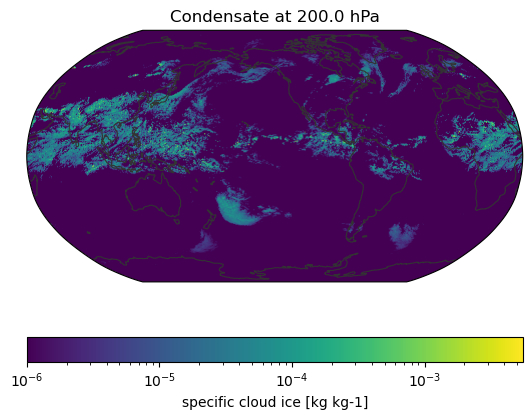

In [8]:
# view
lvl = 20000
img = egh.healpix_show(icon_ds.sel(pressure=lvl).qall[0], norm=mpl.colors.LogNorm(vmin=1e-6))
plt.colorbar(img, orientation="horizontal", label="specific cloud ice [kg kg-1]")
plt.title(f"Condensate at {lvl/100} hPa")

## Data regridding to regular lat/lon grid:

The simplest approach to regridding is to use nearest neighbours after finding the cells matching a lat/lon grid using the `healpix.ang2pix` function. We're also going to sub-sample the dataset in space.

In [9]:
def remap_cells_subset(bbox, grid_spacing, crs):
    lon = xr.DataArray(np.arange(bbox[0], bbox[1], step=grid_spacing), 
                       dims=("lon",), name="lon", 
                       attrs=dict(units="degrees", standard_name="longitude"))
    lat = xr.DataArray(np.arange(bbox[2], bbox[3], step=grid_spacing), 
                       dims=("lat",), name="lat", 
                       attrs=dict(units="degrees", standard_name="latitude"))
    return xr.DataArray(
        healpix.ang2pix(crs.healpix_nside, *np.meshgrid(lon, lat), nest=crs.healpix_order, lonlat=True),
        coords=(lat, lon),
    )

In [10]:
# domain_box = (-12, 0, 10, 17) # west Africa
domain_box = (-12, 0, 10, 17) # west Africa
pix = remap_cells_subset(domain_box, grid_spacing, icon_ds.crs)

In [11]:
tracking_ds = icon_ds.drop_vars(["lat", "lon"], errors="ignore").sel(cell=pix, method="nearest").drop_vars(["cell", "crs",], errors="ignore")

In [12]:
tracking_ds

<xarray.Dataset> Size: 107MB
Dimensions:   (time: 33, pressure: 18, lat: 56, lon: 96)
Coordinates:
  * pressure  (pressure) int64 144B 10000 15000 20000 ... 95000 97500 100000
  * time      (time) datetime64[ns] 264B 2020-08-01T15:00:00 ... 2020-08-01T2...
  * lat       (lat) float64 448B 10.0 10.12 10.25 10.38 ... 16.62 16.75 16.88
  * lon       (lon) float64 768B -12.0 -11.88 -11.75 ... -0.375 -0.25 -0.125
Data variables: (12/18)
    hur       (time, pressure, lat, lon) float32 13MB ...
    hus       (time, pressure, lat, lon) float32 13MB ...
    orog      (lat, lon) float32 22kB ...
    pr        (time, lat, lon) float32 710kB ...
    psl       (time, lat, lon) float32 710kB ...
    qall      (time, pressure, lat, lon) float32 13MB ...
    ...        ...
    ua        (time, pressure, lat, lon) float32 13MB ...
    uas       (time, lat, lon) float32 710kB ...
    va        (time, pressure, lat, lon) float32 13MB ...
    vas       (time, lat, lon) float32 710kB ...
    wa        (time, pressure, lat, lon) float32 13MB ...
    zg        (time, pressure, lat, lon) float32 13MB ...
Attributes:
    hiopy::parent:  PT15M_point_z10_atm

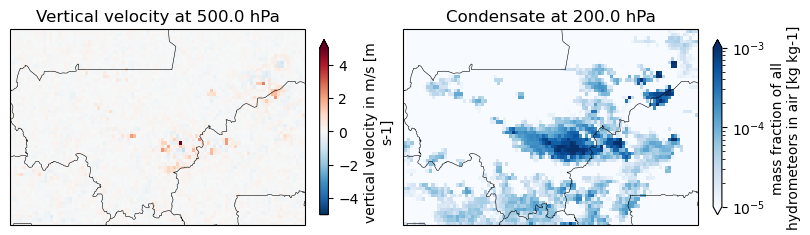

In [13]:
# view
fig, axs = plt.subplots(1,2,figsize=(8,3), subplot_kw={"projection": ccrs.Robinson()}, constrained_layout=True)

ax = axs[0]
lvl = 50000
tracking_ds.sel(pressure=lvl).wa[0].plot(ax=ax, cmap="RdBu_r", norm=mpl.colors.TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5), cbar_kwargs=dict(shrink=.6, ), transform=ccrs.PlateCarree())
ax.set_title(f"Vertical velocity at {lvl/100} hPa")

ax = axs[1]
lvl = 20000
tracking_ds.sel(pressure=lvl).qall[0].plot(ax=ax, cmap="Blues", norm=mpl.colors.LogNorm(vmin=1e-5, vmax=1e-3,), cbar_kwargs=dict(shrink=.6, ), transform=ccrs.PlateCarree())
ax.set_title(f"Condensate at {lvl/100} hPa")

for ax in axs:
    ax.add_feature(cf.COASTLINE, linewidth=0.8)
    ax.add_feature(cf.BORDERS, linewidth=0.4)


## Feature detection and _tobac_ centroid-tracking

Here we use the normal steps:

1. feature_detection
2. _tobac_ centroid-tracking
3. segmentation

1. Start with feature detection

In [14]:
UpdraftFeatures = tobac.feature_detection_multithreshold(
    tracking_ds.wa, 
    dxy=dxy, 
    threshold=[1,5,7,10],
    vertical_coord="pressure",
    position_center='weighted_diff',
    sigma_threshold=1,
    n_min_threshold=8,

)

In [15]:
IceCloudFeatures = tobac.feature_detection_multithreshold(
    tracking_ds.qall.where(tracking_ds.pressure<=75000), # approx. above the freezing level
    dxy=dxy, 
    threshold=[1e-4,],
    vertical_coord="pressure",
    position_center='weighted_diff',
    sigma_threshold=1,
    n_min_threshold=27,
)

2. _tobac_ centroid-tracking

In [16]:
UpdraftTracks = tobac.linking_trackpy(
    UpdraftFeatures, 
    None, 
    dt=900, 
    dxy=dxy, 
    d_max=dxy*2,
    method_linking="predict", 
    stubs=1,
    vertical_coord="pressure",
)

Frame 32: 3 trajectories present.


In [17]:
IceCloudTracks = tobac.linking_trackpy(
    IceCloudFeatures, 
    None, dt=900, 
    dxy=dxy, 
    d_max=dxy*4, 
    method_linking="predict", 
    stubs=2,
    vertical_coord="pressure",
)

Frame 32: 5 trajectories present.


3. perform watershed segmentation

In [18]:
updraft_mask, UpdraftTracks = tobac.segmentation.segmentation(
    UpdraftTracks, 
    tracking_ds.wa, 
    dxy=dxy, 
    threshold=1, 
    seed_3D_flag="box",
    vertical_coord="pressure",
)

In [19]:
ice_cloud_mask, IceCloudTracks = tobac.segmentation.segmentation(
    IceCloudTracks, 
    tracking_ds.qall.where(tracking_ds.pressure<=75000),
    dxy=dxy, 
    threshold=1e-4,
    seed_3D_flag="box",
    vertical_coord="pressure",
)

Finally, add the tracking labels to the watershed masks

In [20]:
def table_to_dataset(table, name, dataset, existing_var="feature"):
    di = table.set_index(existing_var)[name].to_dict()
    feature_array = dataset[existing_var].values
    dataarray = xr.DataArray(np.vectorize(lambda x: di.get(x, 0))(feature_array), dims=dataset[existing_var].dims, coords=dataset[existing_var].coords)
    return dataarray

updraft_mask = updraft_mask.to_dataset(name="feature")
updraft_mask['cell'] = table_to_dataset(table=UpdraftTracks, name='cell', dataset=updraft_mask)

In [21]:
ice_cloud_mask = ice_cloud_mask.to_dataset(name="feature")
ice_cloud_mask['cell'] = table_to_dataset(table=IceCloudTracks, name='cell', dataset=ice_cloud_mask)

View the results

Text(0.5, 1.0, 'tobac updrafts at 500 hPa')

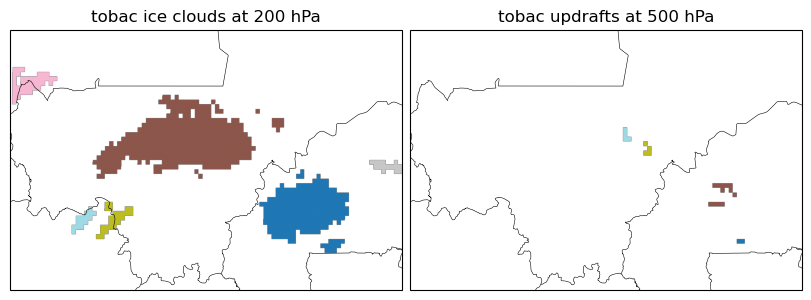

In [22]:
fig, axs = plt.subplots(
    1, 2,
    figsize=(8,3),
    subplot_kw={"projection": ccrs.Robinson()},
    constrained_layout=True,
)

for ax in axs:
    ax.set_extent(domain_box, crs=ccrs.PlateCarree())
    ax.add_feature(cf.COASTLINE, linewidth=0.8)
    ax.add_feature(cf.BORDERS, linewidth=0.4)
    
d1 = ice_cloud_mask.cell.isel(time=10).sel(pressure=20000)
d2 = updraft_mask.cell.isel(time=10).sel(pressure=50000)

im1 = axs[0].imshow(
    d1.where(d1 > 0),
    cmap="tab20",
    extent=domain_box,
    transform=ccrs.PlateCarree(),
)

im2 = axs[1].imshow(
    d2.where(d2 > 0),
    cmap="tab20",
    extent=domain_box,
    transform=ccrs.PlateCarree(),
)

axs[0].set_title("tobac ice clouds at 200 hPa")
axs[1].set_title("tobac updrafts at 500 hPa")

## Extra tracking using eroded-contiguity

Here we add some steps, designed to make sure that anvils are well tracked late into their lifetime when centroid-tracking can get less reliable

1. perform (updrafts) contiguity tracking and (ice clouds) eroded-contiguity tracking
2. combine the results of (1) with the centroid tracks
3. define the final deep convective clouds (updrafts + ice clouds)

In [23]:
IceCloudTracks

,frame,idx,vdim,hdim_1,hdim_2,num,threshold_value,feature,time,timestr,pressure,lat,lon,cell,time_cell,ncells
0,0,1,3.164093,22.153153,59.689189,1554,0.0001,1,2020-08-01 15:00:00,2020-08-01 15:00:00,25820.463320,12.769144,-4.538851,-1,NaT,2802
1,0,2,2.933045,38.129590,82.838013,463,0.0001,2,2020-08-01 15:00:00,2020-08-01 15:00:00,24665.226782,14.766199,-1.645248,2,0 days 00:00:00,955
2,0,3,2.273973,45.753425,87.602740,73,0.0001,3,2020-08-01 15:00:00,2020-08-01 15:00:00,21369.863014,15.719178,-1.049658,3,0 days 00:00:00,40
3,0,4,4.209677,0.774194,58.806452,62,0.0001,4,2020-08-01 15:00:00,2020-08-01 15:00:00,32096.774194,10.096774,-4.649194,-1,NaT,397
4,0,5,3.580645,35.580645,72.935484,31,0.0001,5,2020-08-01 15:00:00,2020-08-01 15:00:00,27903.225806,14.447581,-2.883065,5,0 days 00:00:00,65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,32,1,3.129680,27.386073,42.775571,4380,0.0001,167,2020-08-01 23:00:00,2020-08-01 23:00:00,25648.401826,13.423259,-6.653054,27,0 days 03:15:00,7110
167,32,2,3.939815,21.083333,7.657407,216,0.0001,168,2020-08-01 23:00:00,2020-08-01 23:00:00,29699.074074,12.635417,-11.042824,29,0 days 01:00:00,501
168,32,3,2.346535,44.990099,44.326733,101,0.0001,169,2020-08-01 23:00:00,2020-08-01 23:00:00,21732.673267,15.623762,-6.459158,-1,NaT,230
169,32,4,3.842956,3.468822,8.605081,433,0.0001,170,2020-08-01 23:00:00,2020-08-01 23:00:00,29214.780600,10.433603,-10.924365,14,0 days 07:30:00,951


In [24]:
# IceCloudTracks = IceCloudTracks.drop(columns=['econtiguity','combined','dcc','renumbered_x','renumbered_y'], errors="ignore",)
# UpdraftTracks = IceCloudTracks.drop(columns=['contiguity','combined','dcc','renumbered'], errors="ignore",)

In [25]:
# ice_cloud_mask = ice_cloud_mask.drop_vars(['econtiguity','combined','dcc'], errors="ignore")
# updraft_mask = updraft_mask.drop_vars(['econtiguity','combined','dcc'], errors="ignore")

1. track using eroded-contiguity

There is only one parameter in this method that you need to use for tuning, and that's the erosion threshold. This sets how severly you erode the features before testing for remaining overlap between time steps.

In [26]:
fraction = .5

The name of the input dataarray will need to match the name of the column that mask represents in the feature table. In this case, we're tracking on the "cell" results from (3).

In [28]:
ice_cloud_mask['econtiguity'] = tobac.eroded_contiguity.track_using_eroded_contiguity(
    ice_cloud_mask.cell,
    IceCloudTracks,
    fraction,
    PBC_flag=None,
    vdim="pressure",
    max_object_length=10,
    use_parallel=True,
    name='econtiguity', # what to call the new labels
)

For the updrafts, we don't need the erosion step, as they are usually isolated and don't merge. Instead we will do a simple contiguity check.

In [30]:
updraft_mask['contiguity'], _ = tobac.eroded_contiguity.track_using_contiguity(
    updraft_mask.cell,
    UpdraftTracks,
    PBC_flag=None,
    vdim="pressure",
    name='contiguity',
)

2. combine the results with the centroid tracks

At this point, we have performed two tracking operations (first) using centrois and (second) using eroded-contiguity. Now, we need to make sure that the results are consistent.
    
For example, we don't want an anvil that had its development tracked using centroids and  its decay tracked using eroded-contiguity to not have those two stages nicely linked up in the final product. And note that this can happen, because the labels input into the eroded contiguity step are overidden with it's results, not kept.

So, the first step is to search the two tracked datasets for where objects (ie. tracks) overlap (basically a fancy np.where operation)

In [31]:
EContiguity = pd.DataFrame(range(ice_cloud_mask.econtiguity.max().values), columns=('econtiguity',)) # new to record changes
IceCloudTracks, EContiguity = tobac.multivariate.get_multivariate_label_maps(ice_cloud_mask.cell, IceCloudTracks, 
                                                         ice_cloud_mask.econtiguity, EContiguity,
                                                         name='combined')

In [32]:
Contiguity = pd.DataFrame(range(updraft_mask.contiguity.max().values), columns=('contiguity',)) # new to record changes
UpdraftTracks, _ = tobac.multivariate.get_multivariate_label_maps(updraft_mask.cell, UpdraftTracks,
                                                                  updraft_mask.contiguity, Contiguity,
                                                                  name='combined')

Next step, apply these results to the masks

In [33]:
ice_cloud_mask['combined'] = tobac.multivariate.apply_multivariate_label_maps(ice_cloud_mask.cell, IceCloudTracks, name='combined')

In [34]:
updraft_mask['combined'] = tobac.multivariate.apply_multivariate_label_maps(updraft_mask.cell, UpdraftTracks, name='combined')

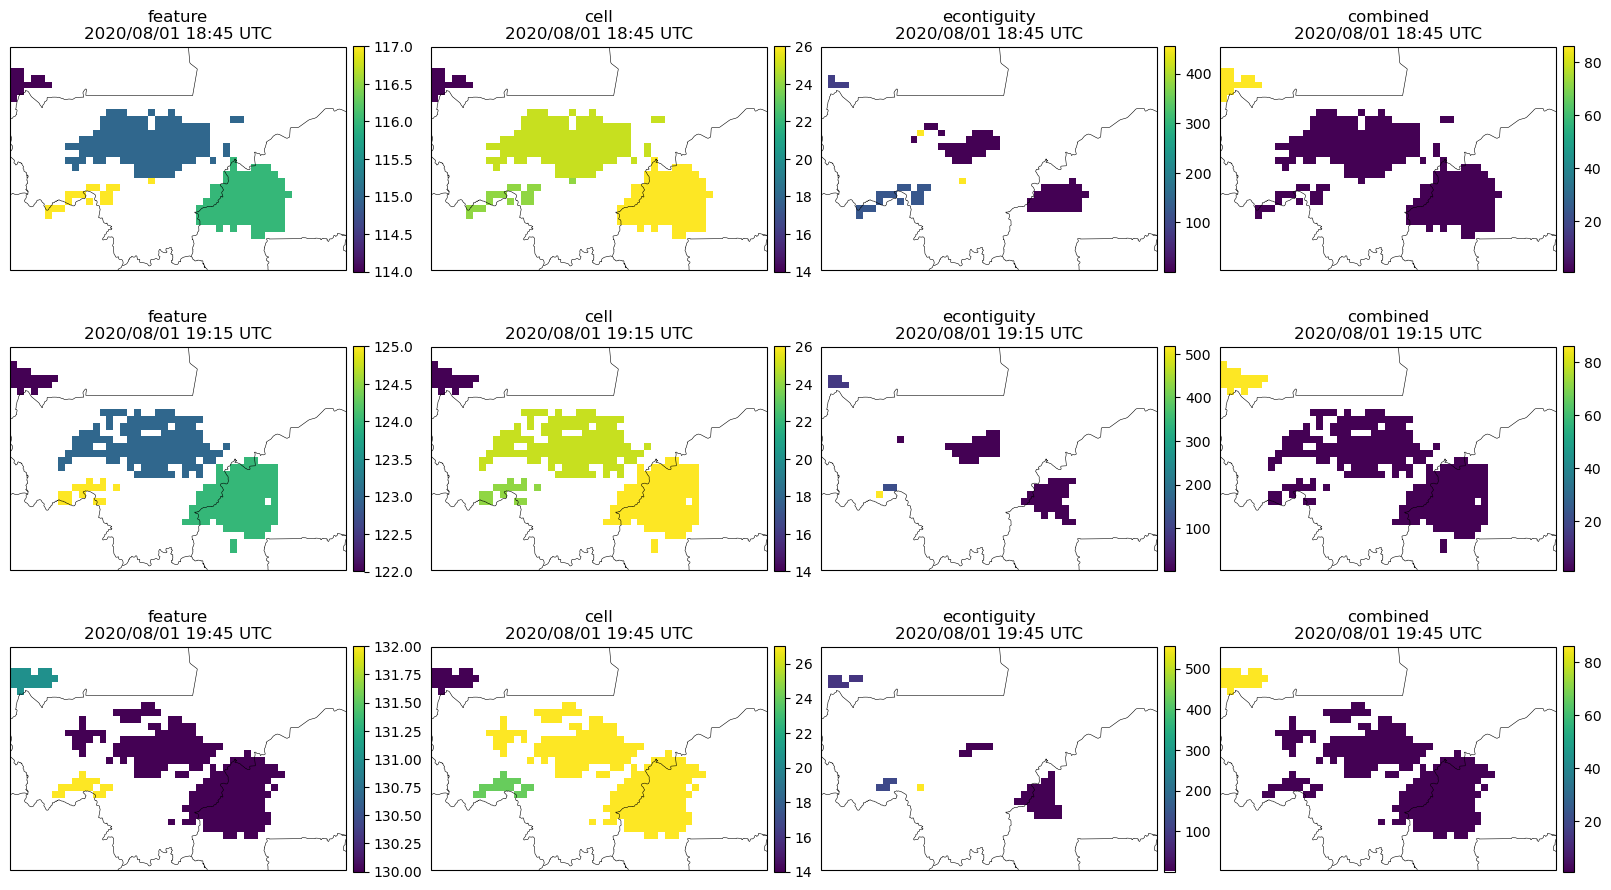

In [50]:
plot_these = [ice_cloud_mask.feature, ice_cloud_mask.cell, ice_cloud_mask.econtiguity, ice_cloud_mask.combined]
N = len(plot_these)

fig, axs = plt.subplots(
    3, N,
    figsize=(N*4,9),
    subplot_kw={"projection": ccrs.Robinson()},
    constrained_layout=True,
)

for i, row in enumerate(axs):
    for j, ax in enumerate(row):
        d = plot_these[j].isel(time=15+i*2).sel(pressure=20000)
    
        im = ax.imshow(
            d.where(d > 0),
            # cmap=make_repeated_tab20_colorbar(d.max().values)[0],
            cmap='viridis',
            extent=domain_box,
            transform=ccrs.PlateCarree(),
        )
        fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
        ax.set_extent(domain_box, crs=ccrs.PlateCarree())
        ax.add_feature(cf.COASTLINE, linewidth=0.8)
        ax.add_feature(cf.BORDERS, linewidth=0.4)
        tstr = d.time.dt.strftime("%Y/%m/%d %H:%M UTC").item()
        ax.set_title(f'{d.name}\n{tstr}')
    

3. define the deep convective clouds

Now we have tracks of updrafts and ice clouds, we combine them by finding out which updrafts were associated with each ice cloud

In [36]:
UpdraftTracks, IceCloudTracks = tobac.multivariate.get_multivariate_label_maps(updraft_mask.combined, UpdraftTracks,
                                                                               ice_cloud_mask.combined, IceCloudTracks,
                                                                               name='dcc')

In [37]:
def force_consecutive_labels(df, v='dcc'):
    unique, consecutive = np.unique(df[v].values, return_inverse=1)
    mapp = pd.DataFrame(np.column_stack([unique, np.arange(unique.size)]), columns=[v, "renumbered"])
    df = df.merge(mapp, left_on=v, right_on=v, how='left')
    df = df.drop(columns=[v,])
    return df.rename(columns={"renumbered":v})

UpdraftTracks = force_consecutive_labels(UpdraftTracks)
IceCloudTracks = force_consecutive_labels(IceCloudTracks)

In [39]:
updraft_mask['dcc'], ice_cloud_mask['dcc'] = tobac.multivariate.apply_multivariate_label_maps(updraft_mask.combined, UpdraftTracks, 
                                                                                              ice_cloud_mask.combined,  IceCloudTracks,
                                                                                              name='dcc')
dcc_systems = np.maximum(updraft_mask.dcc, updraft_mask.dcc).to_dataset(name='systems')
dcc_systems['their_updrafts'] = updraft_mask.combined # keep unique labels for each updraft

We can compare the results to what we'd get is we only used centroid-tracking


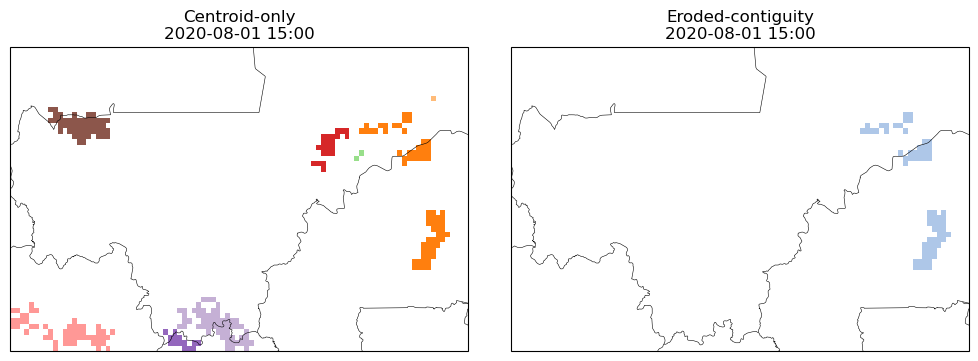

In [41]:
import matplotlib.animation as animation
def make_repeated_tab20_colorbar(x):
    x = int(x)
    base = plt.get_cmap("tab20").colors
    colors = [base[i % len(base)] for i in range(x)]
    cmap = mpl.colors.ListedColormap(colors, name=f"repeated_tab20_{x}")
    norm = mpl.colors.BoundaryNorm(np.arange(-0.5, x + 0.5, 1), cmap.N)
    return cmap, norm

fig, axs = plt.subplots(
    1, 2,
    figsize=(10, 3.5),
    subplot_kw={"projection": ccrs.Robinson()},
    constrained_layout=True,
)

plev = 30000

for ax in axs:
    ax.set_extent(domain_box, crs=ccrs.PlateCarree())
    ax.add_feature(cf.COASTLINE, linewidth=0.8)
    ax.add_feature(cf.BORDERS, linewidth=0.4)

cmap1, norm1 = make_repeated_tab20_colorbar(IceCloudTracks.cell.max())
cmap2, norm2 = make_repeated_tab20_colorbar(IceCloudTracks.dcc.max())

d1 = ice_cloud_mask.cell.isel(time=0).sel(pressure=plev)
d2 = ice_cloud_mask.dcc.isel(time=0).sel(pressure=plev)

im1 = axs[0].imshow(
    d1.where(d1 > 0),
    cmap=cmap1,
    norm=norm1,
    extent=domain_box,
    transform=ccrs.PlateCarree(),
    animated=True,
)

im2 = axs[1].imshow(
    d2.where(d2 > 0),
    cmap=cmap2,
    norm=norm2,
    extent=domain_box,
    transform=ccrs.PlateCarree(),
    animated=True,
)

title1 = axs[0].set_title("")
title2 = axs[1].set_title("")

def update(frame):
    d1 = ice_cloud_mask.cell.isel(time=frame).sel(pressure=plev)
    d2 = ice_cloud_mask.dcc.isel(time=frame).sel(pressure=plev)

    im1.set_data(d1.where(d1 > 0))
    im2.set_data(d2.where(d2 > 0))

    ts = str(updraft_mask.time.dt.strftime("%Y-%m-%d %H:%M").values[frame])
    title1.set_text(f"Centroid-only\n{ts}")
    title2.set_text(f"Eroded-contiguity\n{ts}")

    return im1, im2, title1, title2

ani = animation.FuncAnimation(
    fig,
    update,
    frames=updraft_mask.sizes["time"],
    interval=300,
    blit=False,
)

In [42]:
ani.save("africa_tracks.gif", writer="pillow", fps=2)